# Satellite-Derived Bathymetry from Sentinel-2 and ICESat-2

**Developer: Ali Reza Payandeh**

This notebook provides a workflow for deriving shallow-water bathymetry from Sentinel-2 surface reflectance and ICESat-2 ATL24 bathymetric observations using XGBoost.

The included dataset is provided as an example application of the workflow. The code can be adapted to other coastal and inland-water environments by replacing the input Sentinel-2 and ICESat-2 data and adjusting the study-area-specific filtering parameters where necessary.

- `S2B_MSI_2024_11_28_08_59_38_T33HYD_L2R.nc`
- `atl24x_rgt_228_cycle_5_gt3r.csv`

The notebook creates an `output` folder automatically and writes the figures and final GeoTIFF there.

## Imports

In [80]:
from pathlib import Path
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib as mpl
import rasterio
from rasterio.transform import from_origin
from scipy.spatial import cKDTree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import optuna
import cmocean

print("Imports complete")

Imports complete


## Files and settings

In [82]:
# Keep the notebook and both input files together in the SDB folder.
BASE_DIR = Path.cwd()
SENTINEL_FILE = BASE_DIR / "S2B_MSI_2024_11_28_08_59_38_T33HYD_L2R.nc"
ICESAT2_FILE = BASE_DIR / "atl24x_rgt_228_cycle_5_gt3r.csv"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

# Langebaan limits used in the original analysis.
LON_MIN, LON_MAX = 17.81, 18.133030
LAT_MIN, LAT_MAX = -33.216, -32.99
NDWI_THRESHOLD = -0.1
N_TRIALS = 20
RANDOM_STATE = 42
PREDICTION_CHUNK = 250_000

missing = [p.name for p in (SENTINEL_FILE, ICESAT2_FILE) if not p.exists()]
if missing:
    raise FileNotFoundError("Missing file(s) in the SDB folder: " + ", ".join(missing))

print("Sentinel-2:", SENTINEL_FILE.name)
print("ICESat-2:", ICESAT2_FILE.name)

Sentinel-2: S2B_MSI_2024_11_28_08_59_38_T33HYD_L2R.nc
ICESat-2: atl24x_rgt_228_cycle_5_gt3r.csv


## Read Sentinel-2 data

In [84]:
# This example uses the ACOLITE surface-reflectance bands needed by the SDB model.
ds = nc.Dataset(SENTINEL_FILE, "r", format="NETCDF4")

required_variables = [
    "lon", "lat", "rhos_492", "rhos_559", "rhos_665",
    "rhos_704", "rhos_739", "rhos_780", "rhos_833"
]
missing_variables = [name for name in required_variables if name not in ds.variables]
if missing_variables:
    ds.close()
    raise KeyError("The Sentinel-2 file is missing: " + ", ".join(missing_variables))

def read_nc(name):
    return np.ma.filled(ds.variables[name][:], np.nan).astype(np.float32)

lon_grid = read_nc("lon")
lat_grid = read_nc("lat")
b2 = read_nc("rhos_492")
b3 = read_nc("rhos_559")
b4 = read_nc("rhos_665")
b5 = read_nc("rhos_704")
b6 = read_nc("rhos_739")
b7 = read_nc("rhos_780")
b8 = read_nc("rhos_833")
ds.close()

rows, cols = lon_grid.shape
print(f"Sentinel-2 grid: {rows} x {cols}")

Sentinel-2 grid: 2525 x 3059


## Water mask and spectral features

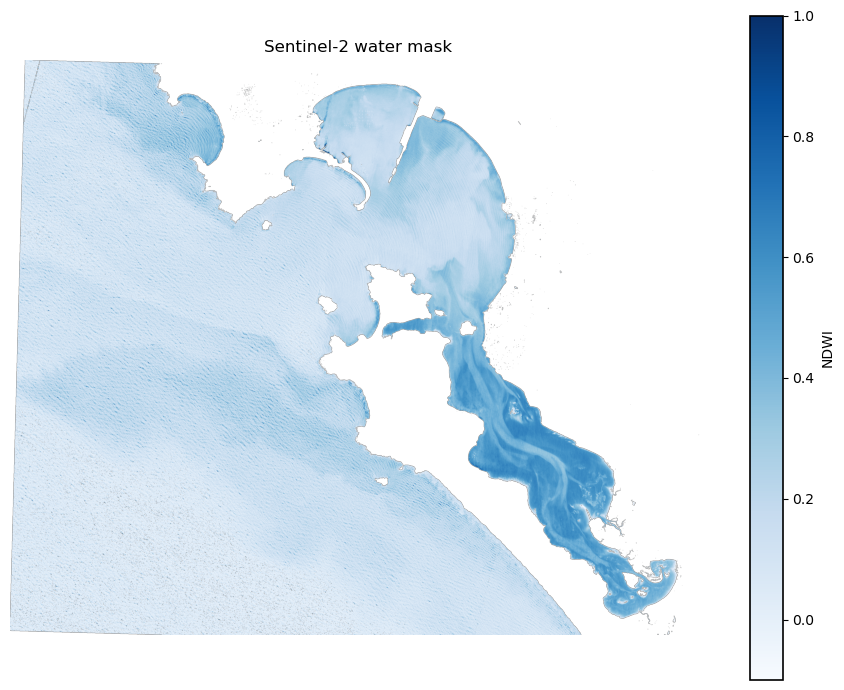

Water pixels used: 4,819,466


In [86]:
# NDWI separates the lagoon water from most land pixels.
denominator = b3 + b8
ndwi = np.divide(
    b3 - b8,
    denominator,
    out=np.full_like(b3, np.nan, dtype=np.float32),
    where=np.isfinite(denominator) & (denominator != 0)
)

roi_mask = (
    (lon_grid >= LON_MIN) & (lon_grid <= LON_MAX) &
    (lat_grid >= LAT_MIN) & (lat_grid <= LAT_MAX)
)
finite_bands = (
    np.isfinite(b2) & np.isfinite(b3) & np.isfinite(b4) &
    np.isfinite(b5) & np.isfinite(b6) & np.isfinite(b7) &
    np.isfinite(b8) & np.isfinite(ndwi)
)
water_mask = roi_mask & finite_bands & (ndwi > NDWI_THRESHOLD)

plt.figure(figsize=(9, 7))
plt.imshow(np.where(water_mask, ndwi, np.nan), cmap="Blues", vmin=-0.1, vmax=1)
plt.colorbar(label="NDWI")
plt.title("Sentinel-2 water mask")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Water pixels used: {water_mask.sum():,}")

In [87]:
# Build the eight predictors used in the original XGBoost model.
valid_flat_idx = np.flatnonzero(water_mask.ravel())

def take_valid(array):
    return array.ravel()[valid_flat_idx].astype(np.float32)

pixel_lon = take_valid(lon_grid)
pixel_lat = take_valid(lat_grid)
v_b2 = take_valid(b2)
v_b3 = take_valid(b3)
v_b4 = take_valid(b4)
v_b5 = take_valid(b5)
v_b6 = take_valid(b6)
v_b7 = take_valid(b7)
v_b8 = take_valid(b8)
v_ndwi = take_valid(ndwi)

eps = np.float32(1e-6)
b2_safe = np.maximum(v_b2, eps)
b3_safe = np.maximum(v_b3, eps)
b4_safe = np.maximum(v_b4, eps)
b8_safe = np.maximum(v_b8, eps)

sentinel_features = np.column_stack((
    b2_safe / b3_safe,
    b2_safe / b4_safe,
    b3_safe / b8_safe,
    b4_safe / b8_safe,
    v_ndwi,
    v_b5,
    v_b6,
    v_b7
)).astype(np.float32)

print("Feature matrix:", sentinel_features.shape)

# The source scene is large, so release arrays that are no longer needed.
del lon_grid, lat_grid, b2, b3, b4, b5, b6, b7, b8
del v_b2, v_b3, v_b4, v_b5, v_b6, v_b7, v_b8, v_ndwi
del ndwi, roi_mask, finite_bands, water_mask

Feature matrix: (4819466, 8)


## Read and filter ICESat-2 ATL24

In [89]:
icesat = pd.read_csv(ICESAT2_FILE)

required_columns = ["lon", "lat", "ortho_h", "class_ph", "confidence", "x_atc", "y_atc"]
missing_columns = [name for name in required_columns if name not in icesat.columns]
if missing_columns:
    raise KeyError("The ICESat-2 file is missing: " + ", ".join(missing_columns))

# The along-track limits remove the sections of this track that were excluded in the original analysis.
x0 = icesat["x_atc"].iloc[0]
icesat_filtered = icesat[
    (icesat["class_ph"] == 40) &
    (icesat["confidence"] > 0.6) &
    ((icesat["x_atc"] - x0) > 2000) &
    ((icesat["x_atc"] - x0) < 15000)
].copy()

if len(icesat_filtered) < 50:
    raise ValueError("Too few ICESat-2 bathymetric points remained after filtering.")

print(f"ATL24 points before filtering: {len(icesat):,}")
print(f"ATL24 points used: {len(icesat_filtered):,}")

ATL24 points before filtering: 3,479
ATL24 points used: 1,907


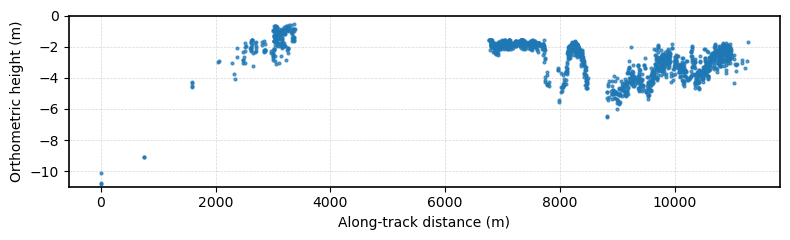

In [90]:
start_x = icesat_filtered["x_atc"].min()

plt.figure(figsize=(8, 2.5))
plt.plot(
    icesat_filtered["x_atc"] - start_x,
    icesat_filtered["ortho_h"],
    ".",
    markersize=4,
    alpha=0.7
)
plt.xlabel("Along-track distance (m)")
plt.ylabel("Orthometric height (m)")
plt.ylim(-11, 0)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ICESat2_ATL24_profile.png", dpi=300, bbox_inches="tight")
plt.show()

## Match ICESat-2 points to Sentinel-2 pixels

In [92]:
# A local meter-based coordinate system is enough for nearest-neighbor matching over this small domain.
lon0 = float(np.nanmean(pixel_lon))
lat0 = float(np.nanmean(pixel_lat))
cos_lat0 = np.cos(np.deg2rad(lat0))

def lonlat_to_xy(lon, lat):
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    x = (lon - lon0) * 111320.0 * cos_lat0
    y = (lat - lat0) * 110540.0
    return np.column_stack((x, y))

pixel_xy = lonlat_to_xy(pixel_lon, pixel_lat)
icesat_xy = lonlat_to_xy(icesat_filtered["lon"].to_numpy(), icesat_filtered["lat"].to_numpy())

tree = cKDTree(pixel_xy)
match_distance, matched_idx = tree.query(icesat_xy, k=1, workers=-1)

X = sentinel_features[matched_idx]
Y = icesat_filtered["ortho_h"].to_numpy(dtype=np.float32)

print("Training samples:", X.shape[0])
print(f"Median Sentinel/ICESat-2 match distance: {np.median(match_distance):.1f} m")
print(f"95th percentile match distance: {np.percentile(match_distance, 95):.1f} m")

Training samples: 1907
Median Sentinel/ICESat-2 match distance: 4.1 m
95th percentile match distance: 6.0 m


## Train XGBoost with Bayesian optimization

In [94]:
sample_idx = np.arange(X.shape[0])
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(
    X, Y, sample_idx, test_size=0.10, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1716, 8)
X_test: (191, 8)


In [95]:
# Keep the search modest for the shareable example. Increase N_TRIALS for a more exhaustive search.
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train, Y_train, cv=3, scoring="neg_mean_squared_error"
    )
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS)

best_params = {
    **study.best_params,
    "objective": "reg:squarederror",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}
print("Best parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

Best parameters:
  n_estimators: 212
  max_depth: 15
  learning_rate: 0.22227824312530747
  subsample: 0.7993292420985183
  colsample_bytree: 0.5780093202212182
  gamma: 0.7799726016810132
  reg_alpha: 0.11616722433639892
  reg_lambda: 1.7323522915498704
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1


In [96]:
best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)
bias = np.mean(Y_pred - Y_test)

print(f"RMSE: {rmse:.2f} m")
print(f"R²: {r2:.2f}")
print(f"Bias: {bias:.2f} m")

RMSE: 0.43 m
R²: 0.80
Bias: -0.08 m


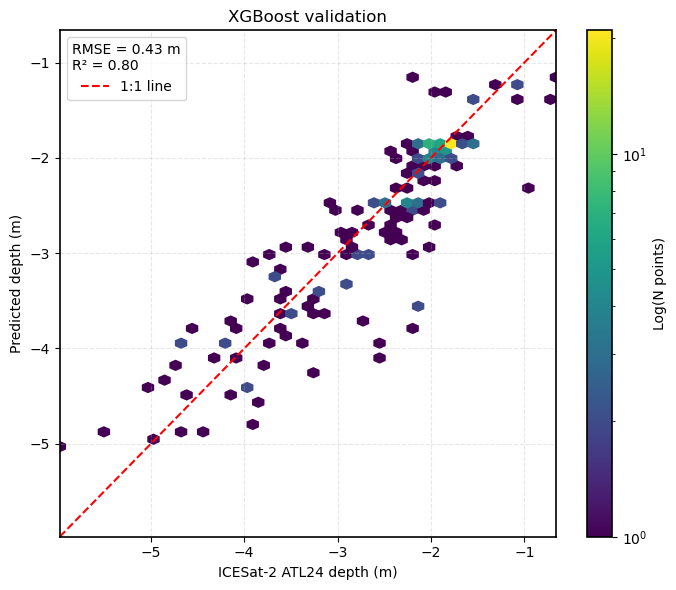

In [97]:
mpl.rcParams["axes.linewidth"] = 1.2

plt.figure(figsize=(7, 6))
hb = plt.hexbin(Y_test, Y_pred, gridsize=45, cmap="viridis", mincnt=1, bins="log")

lims = [
    min(float(np.min(Y_test)), float(np.min(Y_pred))),
    max(float(np.max(Y_test)), float(np.max(Y_pred)))
]
plt.plot(lims, lims, "r--", linewidth=1.5, label="1:1 line")
plt.xlabel("ICESat-2 ATL24 depth (m)")
plt.ylabel("Predicted depth (m)")
plt.title("XGBoost validation")
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title=f"RMSE = {rmse:.2f} m\nR² = {r2:.2f}")
plt.colorbar(hb, label="Log(N points)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "XGBoost_validation.png", dpi=300, bbox_inches="tight")
plt.show()

## Predict bathymetry for the Sentinel-2 scene

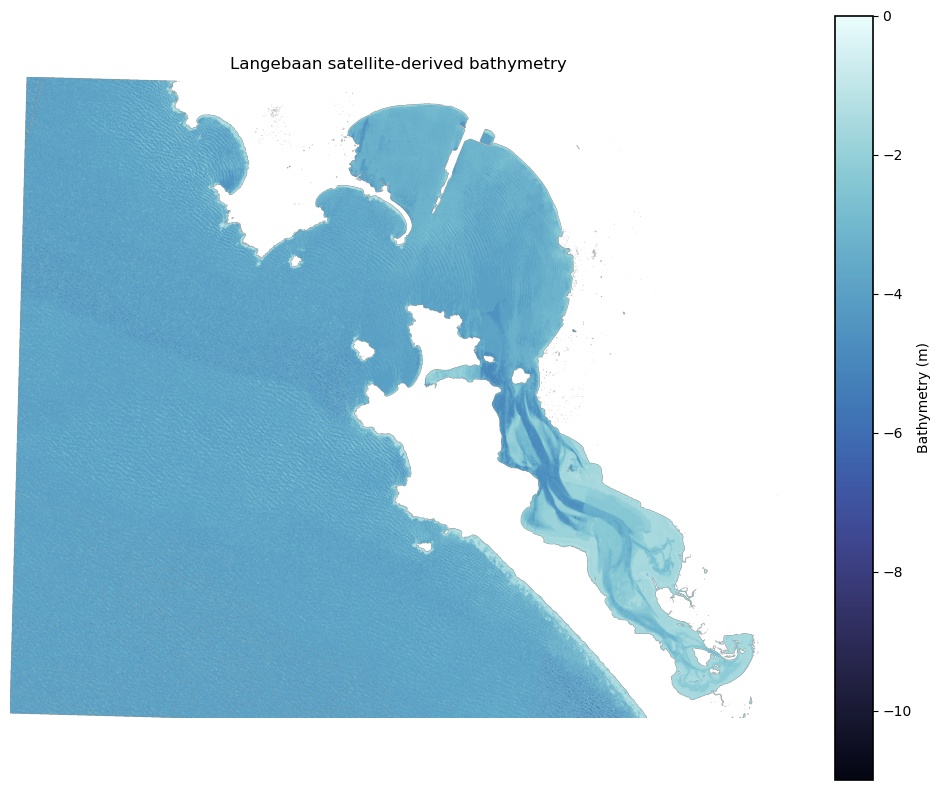

In [99]:
# Predict in chunks so the full-resolution scene does not need one very large model call.
predicted_valid = np.empty(sentinel_features.shape[0], dtype=np.float32)

for start in range(0, sentinel_features.shape[0], PREDICTION_CHUNK):
    end = min(start + PREDICTION_CHUNK, sentinel_features.shape[0])
    predicted_valid[start:end] = best_model.predict(sentinel_features[start:end])

bathymetry_native = np.full(rows * cols, np.nan, dtype=np.float32)
bathymetry_native[valid_flat_idx] = predicted_valid
bathymetry_native = bathymetry_native.reshape(rows, cols)

plt.figure(figsize=(10, 8))
plt.imshow(bathymetry_native, cmap=cmocean.cm.ice, vmin=-11, vmax=0)
plt.colorbar(label="Bathymetry (m)")
plt.title("Langebaan satellite-derived bathymetry")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Langebaan_SDB_native_grid.png", dpi=300, bbox_inches="tight")
plt.show()

## Export a 10 m GeoTIFF

The ACOLITE product stores latitude and longitude as 2-D arrays, so the predicted water pixels are mapped to a regular WGS84 grid before export. Nearest valid Sentinel-2 pixels farther than 15 m are left as NoData, which keeps land areas from being filled with bathymetry.

In [101]:
OUTPUT_RESOLUTION_M = 10.0
MAX_SOURCE_DISTANCE_M = 15.0
NODATA = -9999.0

dx = OUTPUT_RESOLUTION_M / (111320.0 * cos_lat0)
dy = OUTPUT_RESOLUTION_M / 110540.0
ncols = int(np.ceil((LON_MAX - LON_MIN) / dx))
nrows = int(np.ceil((LAT_MAX - LAT_MIN) / dy))

lon_centers = LON_MIN + (np.arange(ncols) + 0.5) * dx
bathymetry_regular = np.full((nrows, ncols), np.nan, dtype=np.float32)

# Query the output grid a few rows at a time to keep memory use reasonable.
row_chunk = 200
for r0 in range(0, nrows, row_chunk):
    r1 = min(r0 + row_chunk, nrows)
    lat_centers = LAT_MAX - (np.arange(r0, r1) + 0.5) * dy
    grid_lon, grid_lat = np.meshgrid(lon_centers, lat_centers)
    target_xy = lonlat_to_xy(grid_lon.ravel(), grid_lat.ravel())
    distance, source_idx = tree.query(target_xy, k=1, workers=-1)
    values = predicted_valid[source_idx].astype(np.float32)
    values[distance > MAX_SOURCE_DISTANCE_M] = np.nan
    bathymetry_regular[r0:r1, :] = values.reshape(r1 - r0, ncols)

transform = from_origin(LON_MIN, LAT_MAX, dx, dy)
tif_file = OUTPUT_DIR / "Langebaan_SDB_example_10m.tif"
write_data = np.where(np.isfinite(bathymetry_regular), bathymetry_regular, NODATA).astype(np.float32)

with rasterio.open(
    tif_file,
    "w",
    driver="GTiff",
    height=nrows,
    width=ncols,
    count=1,
    dtype="float32",
    crs="EPSG:4326",
    transform=transform,
    nodata=NODATA,
    compress="deflate"
) as dst:
    dst.write(write_data, 1)

print("Saved:", tif_file)

Saved: /Users/payandeh/Desktop/SDB/output/Langebaan_SDB_example_10m.tif


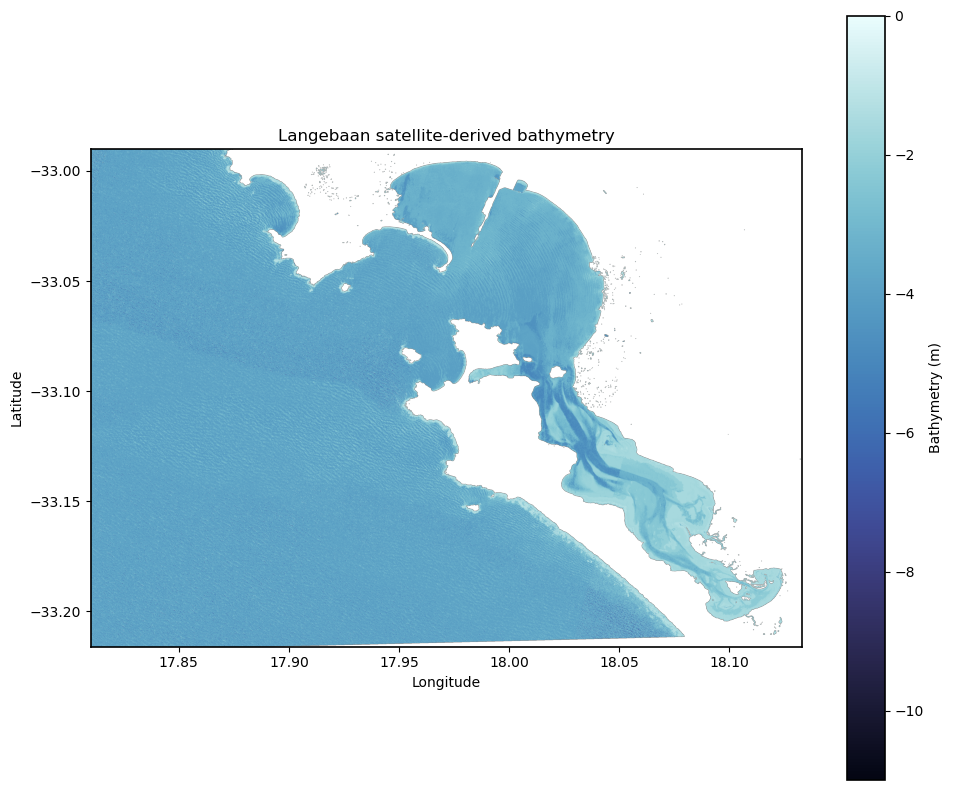

Saved: /Users/payandeh/Desktop/SDB/output/Langebaan_SDB_example.png
Done.


In [102]:
plt.figure(figsize=(10, 8))
plt.imshow(
    bathymetry_regular,
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    origin="upper",
    cmap=cmocean.cm.ice,
    vmin=-11,
    vmax=0,
    aspect="equal"
)
plt.colorbar(label="Bathymetry (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Langebaan satellite-derived bathymetry")
plt.tight_layout()

final_png = OUTPUT_DIR / "Langebaan_SDB_example.png"
plt.savefig(final_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", final_png)
print("Done.")